In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# Load data đã clean từ bài 02
df = pd.read_csv('train_cleaned.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(df.shape)
df.head()

(844392, 22)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,...,WeekOfYear,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1097,2,2013-01-01,5961,1405,1,0,a,1,2013,...,1,b,b,720.0,3.0,2002.0,0,0.0,0.0,NaN
1,85,2,2013-01-01,4220,619,1,0,a,1,2013,...,1,b,a,1870.0,10.0,2011.0,0,0.0,0.0,NaN
2,259,2,2013-01-01,6851,1444,1,0,a,1,2013,...,1,b,b,210.0,0.0,0.0,0,0.0,0.0,NaN
3,262,2,2013-01-01,17267,2875,1,0,a,1,2013,...,1,b,a,1180.0,5.0,2013.0,0,0.0,0.0,NaN
4,274,2,2013-01-01,3102,729,1,0,a,1,2013,...,1,b,b,3640.0,0.0,0.0,1,10.0,2013.0,"Jan,Apr,Jul,Oct"


In [2]:
# Split: dùng 6 tuần cuối làm test (giống thực tế forecast)
cutoff = df['Date'].max() - pd.Timedelta(weeks=6)

train = df[df['Date'] <= cutoff].copy()
test  = df[df['Date'] > cutoff].copy()

print(f"Train: {train['Date'].min().date()} → {train['Date'].max().date()} | {len(train):,} rows")
print(f"Test:  {test['Date'].min().date()} → {test['Date'].max().date()} | {len(test):,} rows")

Train: 2013-01-01 → 2015-06-19 | 804,110 rows
Test:  2015-06-20 → 2015-07-31 | 40,282 rows


In [3]:
# =====================
# SECTION 3: BASELINE MODEL
# =====================

# Baseline 1: Mean Sales (dự đoán = trung bình sales của train)
mean_sales = train['Sales'].mean()
test = test.copy()
test['pred_mean'] = mean_sales

# Baseline 2: Last value (dự đoán = sales trung bình của 7 ngày cuối train)
last_week_mean = train[train['Date'] >= train['Date'].max() - pd.Timedelta(days=7)]['Sales'].mean()
test['pred_last'] = last_week_mean

# Tính MAPE (chỉ tính những ngày store mở - Sales > 0)
test_open = test[test['Sales'] > 0].copy()

mape_mean = mean_absolute_percentage_error(test_open['Sales'], test_open['pred_mean'])
mape_last = mean_absolute_percentage_error(test_open['Sales'], test_open['pred_last'])

print("=== BASELINE RESULTS ===")
print(f"MAPE - Mean Baseline:      {mape_mean:.2%}")
print(f"MAPE - Last Value Baseline:{mape_last:.2%}")

=== BASELINE RESULTS ===
MAPE - Mean Baseline:      38.55%
MAPE - Last Value Baseline:44.91%


In [4]:
# =====================
# SECTION 4: LINEAR REGRESSION
# =====================

# Chọn features (numeric only, không dùng cột target và date)
features = ['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday',
            'Year', 'Month', 'Day', 'WeekOfYear']

X_train = train[features]
y_train = train['Sales']

X_test = test[features]
y_test = test['Sales']

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
test['pred_lr'] = lr.predict(X_test)

# MAPE (chỉ tính Sales > 0)
test_open = test[test['Sales'] > 0].copy()
mape_lr = mean_absolute_percentage_error(test_open['Sales'], test_open['pred_lr'])

print("=== LINEAR REGRESSION ===")
print(f"MAPE: {mape_lr:.2%}")

=== LINEAR REGRESSION ===
MAPE: 35.36%


In [5]:
# =====================
# SECTION 5: RANDOM FOREST
# =====================

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,        # giới hạn depth để chạy nhanh hơn
    n_jobs=-1,           # dùng tất cả CPU cores
    random_state=42
)

rf.fit(X_train, y_train)

test['pred_rf'] = rf.predict(X_test)

test_open = test[test['Sales'] > 0].copy()
mape_rf = mean_absolute_percentage_error(test_open['Sales'], test_open['pred_rf'])

print("=== RANDOM FOREST ===")
print(f"MAPE: {mape_rf:.2%}")


=== RANDOM FOREST ===
MAPE: 37.93%


=== MODEL COMPARISON ===
              Model  MAPE_%
  Linear Regression   35.36
      Random Forest   37.93
      Mean Baseline   38.55
Last Value Baseline   44.91


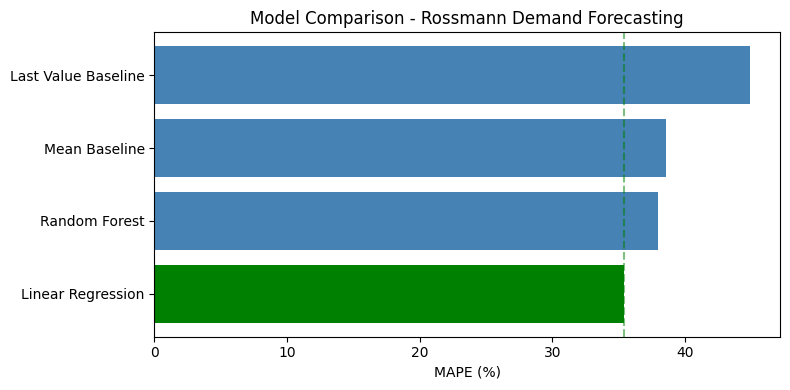

In [6]:
# =====================
# SECTION 6: MODEL COMPARISON
# =====================

results = pd.DataFrame({
    'Model': ['Mean Baseline', 'Last Value Baseline', 'Linear Regression', 'Random Forest'],
    'MAPE': [mape_mean, mape_last, mape_lr, mape_rf]
})

results = results.sort_values('MAPE').reset_index(drop=True)
results['MAPE_%'] = (results['MAPE'] * 100).round(2)

print("=== MODEL COMPARISON ===")
print(results[['Model', 'MAPE_%']].to_string(index=False))

# Plot
plt.figure(figsize=(8, 4))
colors = ['green' if x == results['MAPE'].min() else 'steelblue' for x in results['MAPE']]
plt.barh(results['Model'], results['MAPE_%'], color=colors)
plt.xlabel('MAPE (%)')
plt.title('Model Comparison - Rossmann Demand Forecasting')
plt.axvline(x=results['MAPE_%'].min(), color='green', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [7]:
## 📊 Key Findings

- **Best model**: Linear Regression (MAPE 35.36%)
- **Random Forest** underperformed due to `max_depth=10` constraint — 
  deeper trees expected to improve significantly
- All ML models beat the naive baselines, confirming features 
  (Store, DayOfWeek, Promo, Year/Month) carry real signal
- Next step: tune RF depth or try XGBoost for further improvement

SyntaxError: invalid syntax (1331892909.py, line 3)